# Lab Data Preparation : Diabetes 130-US Hospitals (1999-2008)

## 1. Business Understanding

**Contexte** : Les réadmissions hospitalières précoces chez les patients diabétiques
sont coûteuses et révèlent souvent une prise en charge insuffisante. Le dataset
contient 10 ans de données de 130 hôpitaux américains (~100 000 séjours).

**Problématique de classification** : prédire si un patient diabétique sera
réadmis dans les 30 jours suivant sa sortie (`readmitted = <30`).

**Problématique de segmentation** : identifier des profils de patients
(durée de séjour, nombre de médicaments, historique d'hospitalisations, âge)
afin de repérer des groupes à risque.

**Objectifs** : explorer et nettoyer les données, puis construire des modèles
de clustering et de classification, évalués par des métriques adaptées
au déséquilibre de classes (recall, F1, AUC-ROC).


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

In [75]:
df = pd.read_csv("../data/raw/diabetic_data.csv", na_values="?")
print(df.shape)
df.head()
df

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO


In [76]:
#df.info()
#df.describe().T
# Pourcentage de valeurs manquantes par colonne
#missing = (df.isna().mean() * 100).sort_values(ascending=False)
#missing[missing > 0]
# Distribution de la cible
df["readmitted"].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

## 2. Data Understanding

- Dataset : 101 766 séjours, 50 variables (13 numériques, 37 catégorielles).
- Cible `readmitted` : NO (53,9 %), >30 (34,9 %), <30 (11,2 %) : classes déséquilibrées.
- `weight` est manquant à 96,9 % : inexploitable.
- `max_glu_serum` et `A1Cresult` : la valeur "None" signifie test non réalisé,
  et non une donnée manquante : à conserver comme catégorie.
- Les variables *_id sont des codes catégoriels, pas des quantités.
- Les variables number_* sont fortement asymétriques (outliers probables).

In [77]:
# 1. Doublons et patients répétés
print("Lignes dupliquées :", df.duplicated().sum())
print("Encounters uniques :", df["encounter_id"].nunique())
print("Patients uniques   :", df["patient_nbr"].nunique())
# 2. Valeurs des variables catégorielles clés
for col in ["gender", "race", "age", "admission_type_id",
            "discharge_disposition_id", "admission_source_id"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(12))
# 3. Colonnes quasi constantes
cat_cols = df.select_dtypes(exclude="number").columns
for col in cat_cols:
    top = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top > 0.95:
        print(f"{col}: {top:.2%} de la valeur dominante")
    # 4. Mapping officiel des codes
pd.read_csv("../data/raw/IDS_mapping.csv").head(40)

Lignes dupliquées : 0
Encounters uniques : 101766
Patients uniques   : 71518

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- race ---
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--- admission_type_id ---
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

--- discharge_disposition_id ---
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
Name: count, dtype:

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


### Problèmes de qualité identifiés (suite)
- 3 lignes avec gender = Unknown/Invalid : à supprimer.
- race manquante (2,2 %) : catégorie "Unknown".
- Colonnes quasi constantes (médicaments combinés) : à supprimer.
- Patients décédés ou en hospice (discharge_disposition_id 11, 13, 14, 19, 20, 21) :
  non réadmissibles, à exclure.
- admission_type_id 5, 6, 8 : valeurs inconnues à regrouper.

In [78]:
# 1. Doublons et patients répétés
print("Lignes dupliquées :", df.duplicated().sum())
print("Encounters uniques :", df["encounter_id"].nunique())
print("Patients uniques   :", df["patient_nbr"].nunique())
print("Patients avec >1 séjour :", (df["patient_nbr"].value_counts() > 1).sum())
# 2. Toutes les colonnes quasi constantes (seuil 99 %)
for col in df.columns:
    top = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top > 0.99:
        print(f"{col}: {top:.2%}")
# 3. Combien de patients décédés / en hospice ?
exclus = [11, 13, 14, 19, 20, 21]
print("Séjours à exclure :", df["discharge_disposition_id"].isin(exclus).sum())
print(df[df["discharge_disposition_id"].isin(exclus)]["readmitted"].value_counts())
# 4. Âge : affichage ordonné
print(df["age"].value_counts().sort_index())

Lignes dupliquées : 0
Encounters uniques : 101766
Patients uniques   : 71518
Patients avec >1 séjour : 16773
nateglinide: 99.31%
chlorpropamide: 99.92%
acetohexamide: 100.00%
tolbutamide: 99.98%
acarbose: 99.70%
miglitol: 99.96%
troglitazone: 100.00%
tolazamide: 99.96%
examide: 100.00%
citoglipton: 100.00%
glyburide-metformin: 99.31%
glipizide-metformin: 99.99%
glimepiride-pioglitazone: 100.00%
metformin-rosiglitazone: 100.00%
metformin-pioglitazone: 100.00%
Séjours à exclure : 2423
readmitted
NO     2337
<30      43
>30      43
Name: count, dtype: int64
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


### Résultats de la Data Understanding
- Aucun doublon exact ; 71 518 patients uniques pour 101 766 séjours
  (16 773 patients avec plusieurs séjours) : risque de fuite de données
  à gérer lors du split train/test (GroupShuffleSplit sur patient_nbr).
- 15 colonnes de médicaments quasi constantes (>99 %) : à supprimer.
- 2 423 séjours de patients décédés ou en hospice (dont 96,5 % "NO") :
  à exclure, car non réadmissibles.
- age : tranches ordonnées de 10 ans, concentrées entre 50 et 90 ans :
  à encoder de façon ordinale.

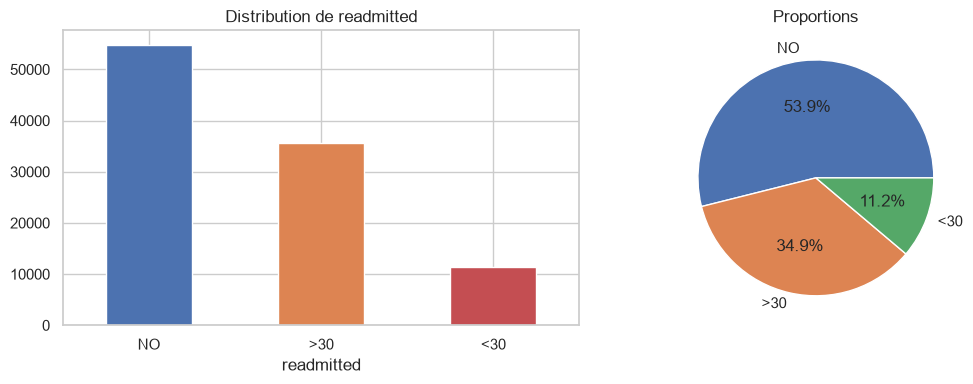

In [79]:
# 1. Distribution de la cible
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["readmitted"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452", "#C44E52"])
ax[0].set_title("Distribution de readmitted")
ax[0].tick_params(axis="x", rotation=0)

df["readmitted"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_ylabel("")
ax[1].set_title("Proportions")
plt.tight_layout()
plt.show()

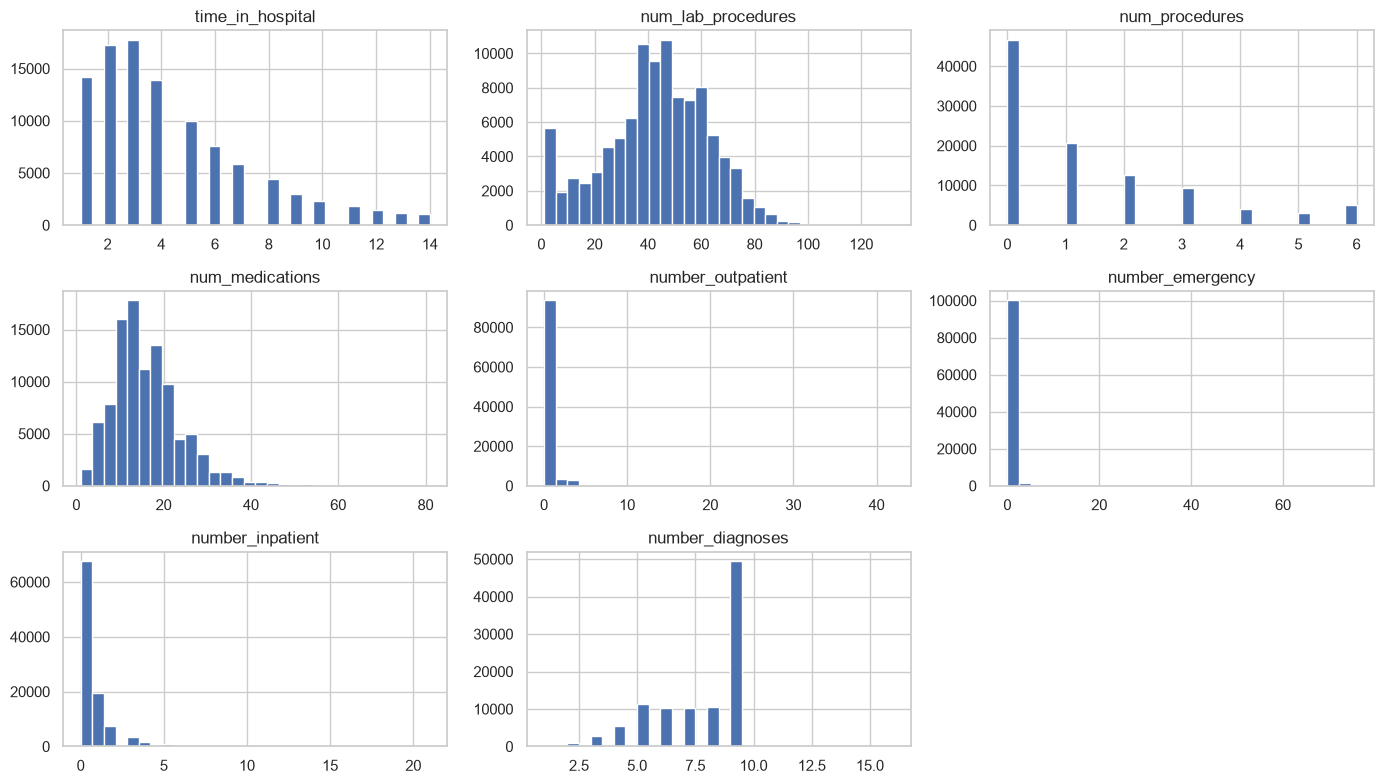

In [80]:
# 2. Distributions des variables numériques
num_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures",
            "num_medications", "number_outpatient", "number_emergency",
            "number_inpatient", "number_diagnoses"]

df[num_cols].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

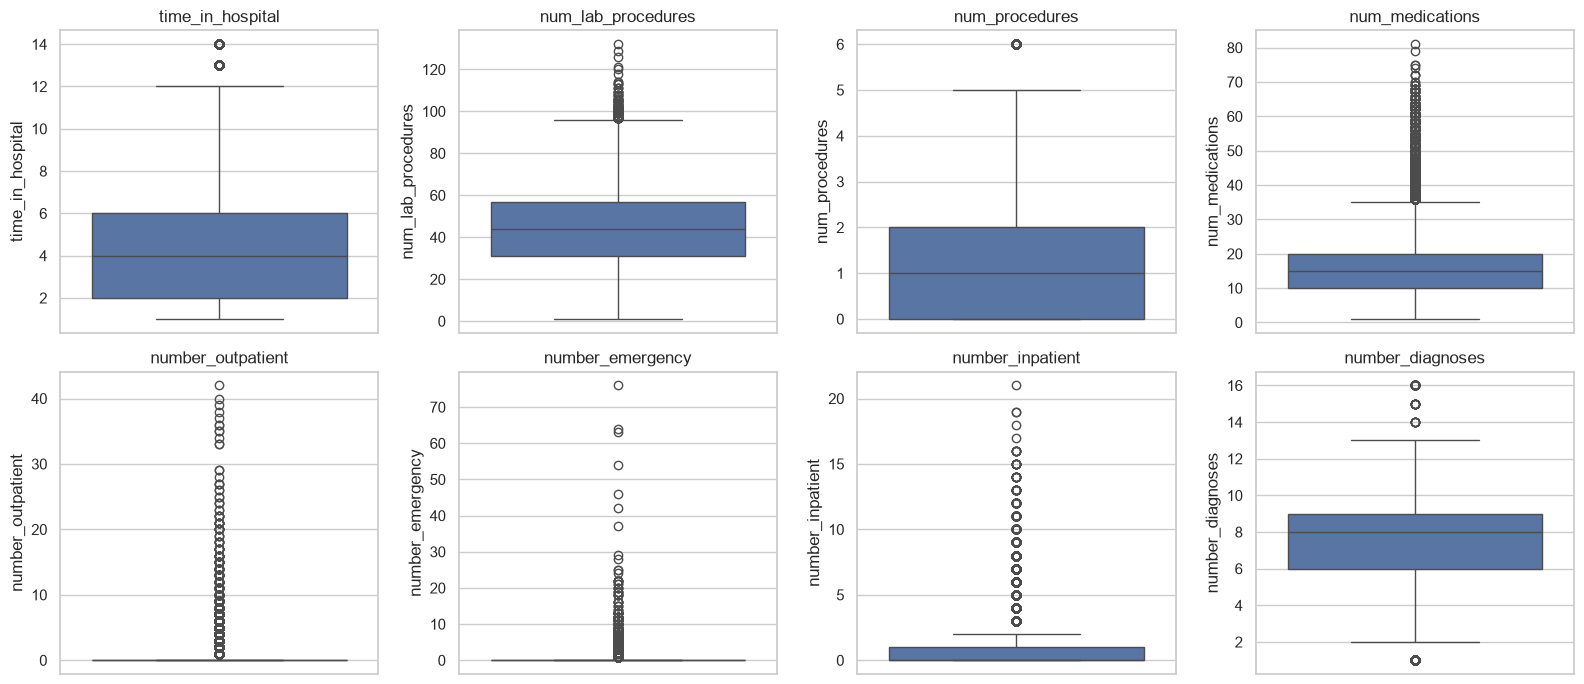

In [81]:
# 3. Boxplots pour repérer les outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

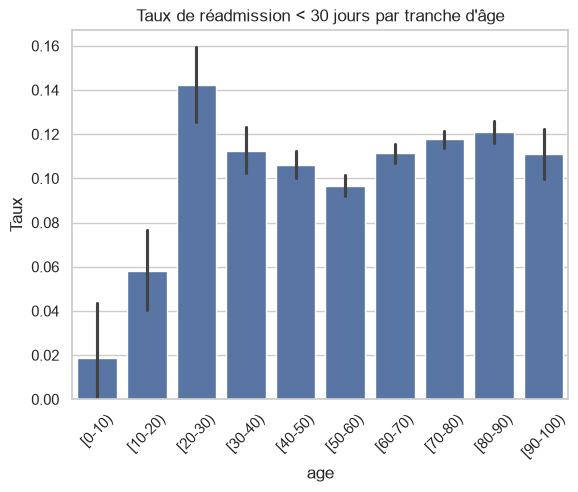

In [82]:
# 4. Réadmission < 30 jours selon l'âge
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
age_order = sorted(df["age"].unique())
sns.barplot(data=df, x="age", y="readmit_30", order=age_order)
plt.xticks(rotation=45)
plt.title("Taux de réadmission < 30 jours par tranche d'âge")
plt.ylabel("Taux")
plt.show()

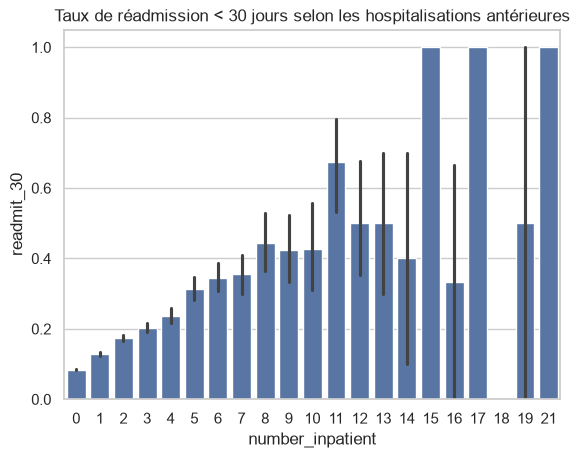

In [83]:
# 5. Réadmission selon number_inpatient (probable variable clé)
sns.barplot(data=df, x="number_inpatient", y="readmit_30")
plt.title("Taux de réadmission < 30 jours selon les hospitalisations antérieures")
plt.show()

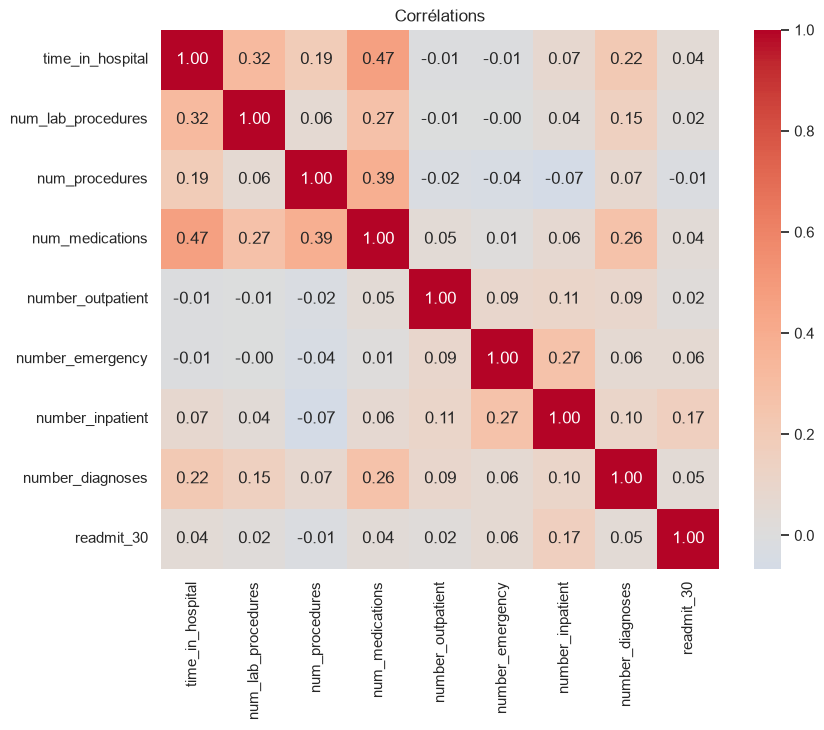

In [84]:
# 6. Matrice de corrélation
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols + ["readmit_30"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations")
plt.show()

## 3. Data Exploration : observations

- La cible est déséquilibrée (<30 : 11,2 %) : accuracy inadaptée, on utilisera recall, F1 et AUC.
- Les variables number_outpatient, number_emergency et number_inpatient sont
  très asymétriques (>90 % de zéros) : transformation log ou regroupement.
- Les outliers (num_medications, number_*) sont médicalement plausibles :
  winsorisation plutôt que suppression.
- number_diagnoses plafonne à 9 (limite de saisie probable).
- number_inpatient est le prédicteur le plus net : le taux de réadmission passe de ~8 %
  (0 hospitalisation) à >30 % (5 et plus). Corrélation avec la cible : 0,17.
- L'âge a un effet modéré et non linéaire (pic à 20-30 ans, petits effectifs).
- Corrélations faibles entre variables (max 0,47) : pas de multicolinéarité grave.
- Corrélations faibles avec la cible : problème difficile, performances modestes attendues.

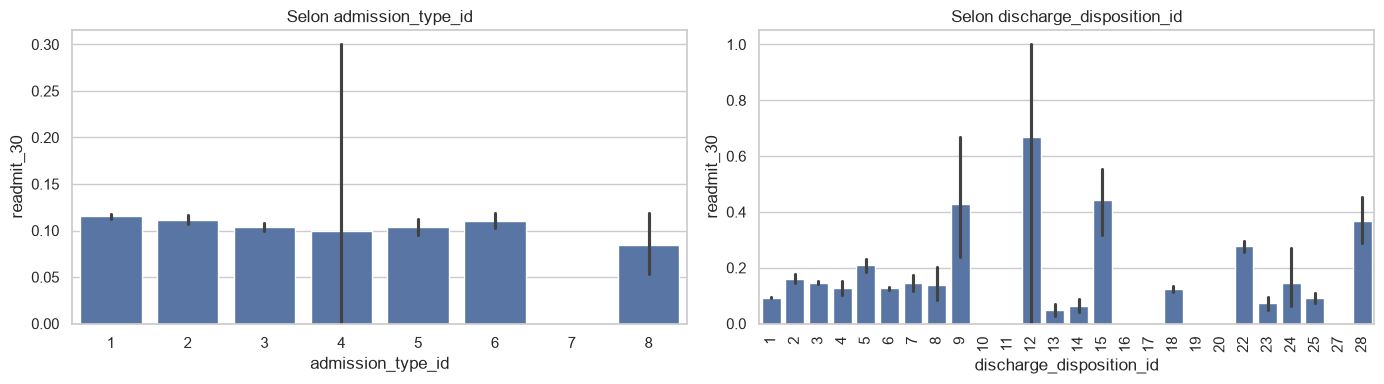

In [85]:
# 1. Réadmission selon le type d'admission et la sortie
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df, x="admission_type_id", y="readmit_30", ax=ax[0])
ax[0].set_title("Selon admission_type_id")
sns.barplot(data=df, x="discharge_disposition_id", y="readmit_30", ax=ax[1])
ax[1].set_title("Selon discharge_disposition_id")
ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

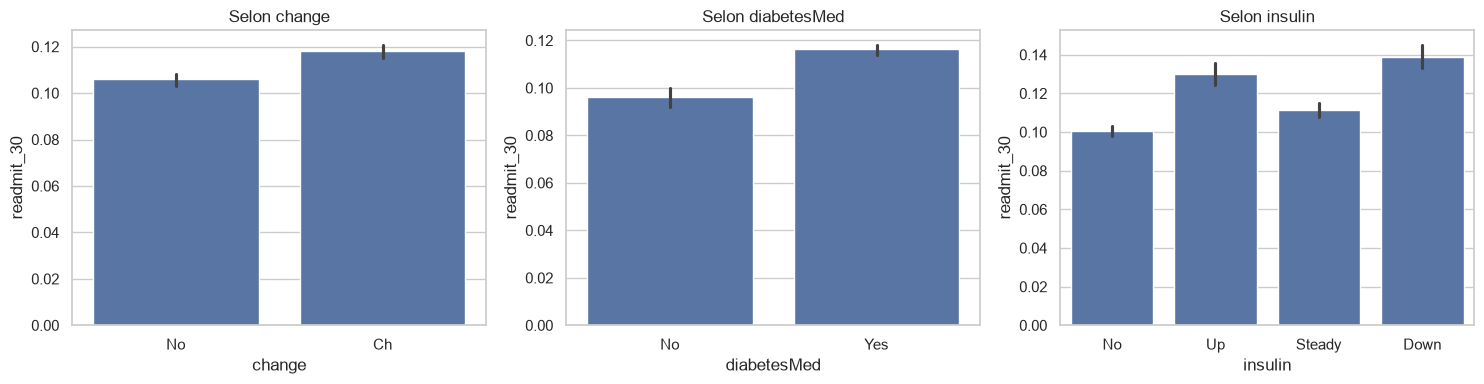

In [86]:
# 2. Réadmission selon le traitement
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ["change", "diabetesMed", "insulin"]):
    sns.barplot(data=df, x=col, y="readmit_30", ax=a)
    a.set_title(f"Selon {col}")
plt.tight_layout()
plt.show()

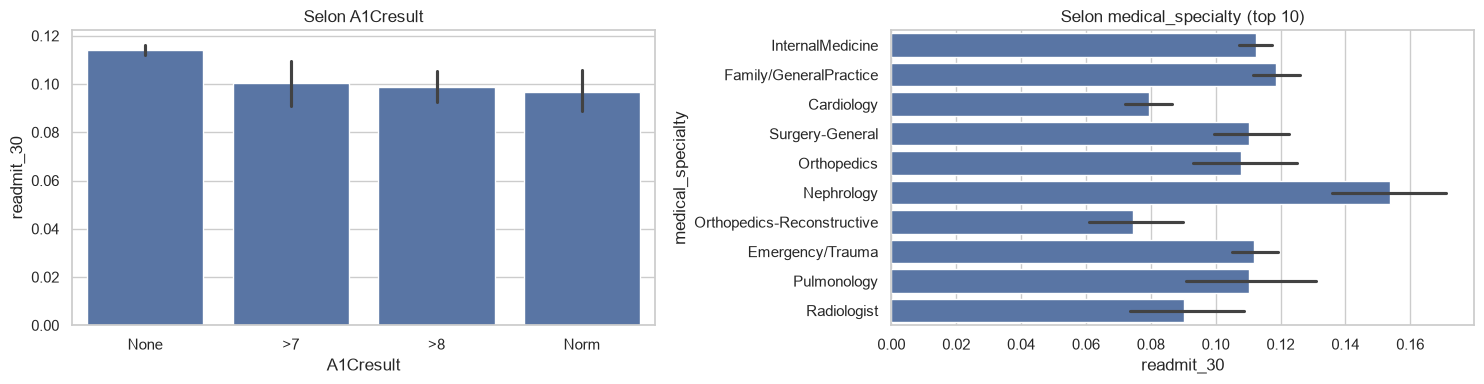

In [87]:
# 3. Réadmission selon le test HbA1c et la spécialité médicale
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=df.fillna({"A1Cresult": "None"}), x="A1Cresult", y="readmit_30", ax=ax[0])
ax[0].set_title("Selon A1Cresult")
top_spec = df["medical_specialty"].value_counts().head(10).index
sns.barplot(data=df[df["medical_specialty"].isin(top_spec)], y="medical_specialty", x="readmit_30", ax=ax[1])
ax[1].set_title("Selon medical_specialty (top 10)")
plt.tight_layout()
plt.show()

In [88]:
# 4. Top 10 des codes diagnostics (diag_1)
df["diag_1"].value_counts().head(10)

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

### Exploration des variables catégorielles
- admission_type_id : peu discriminant ; regrouper les codes inconnus (5, 6, 8) et rares (4, 7).
- discharge_disposition_id : très informatif (5 % à 40 %) ; les transferts vers un autre
  établissement sont à haut risque ; à regrouper en 4-5 catégories.
- Un changement de traitement, la prise de médicaments antidiabétiques et un ajustement
  de l'insuline sont associés à un taux de réadmission plus élevé (diabète instable).
- A1Cresult = None (test non réalisé) a le taux le plus élevé : information utile,
  à conserver comme catégorie "Not_tested".
- medical_specialty : forte cardinalité et 49 % de manquants ; garder le top 10-15,
  "Unknown" et "Other".
- diag_1/2/3 : plus de 700 codes CIM-9 ; regroupement en ~9 grandes catégories.

In [89]:
# 1. Valeurs des colonnes médicaments restantes (celles qu'on va garder)
med_cols = ["metformin", "repaglinide", "glimepiride", "glipizide", "glyburide",
            "pioglitazone", "rosiglitazone", "insulin"]
for c in med_cols:
    print(c, df[c].value_counts(normalize=True).round(3).to_dict())

metformin {'No': 0.804, 'Steady': 0.18, 'Up': 0.01, 'Down': 0.006}
repaglinide {'No': 0.985, 'Steady': 0.014, 'Up': 0.001, 'Down': 0.0}
glimepiride {'No': 0.949, 'Steady': 0.046, 'Up': 0.003, 'Down': 0.002}
glipizide {'No': 0.875, 'Steady': 0.112, 'Up': 0.008, 'Down': 0.006}
glyburide {'No': 0.895, 'Steady': 0.091, 'Up': 0.008, 'Down': 0.006}
pioglitazone {'No': 0.928, 'Steady': 0.069, 'Up': 0.002, 'Down': 0.001}
rosiglitazone {'No': 0.937, 'Steady': 0.06, 'Up': 0.002, 'Down': 0.001}
insulin {'No': 0.466, 'Steady': 0.303, 'Down': 0.12, 'Up': 0.111}


In [90]:
# 2. Nombre de valeurs distinctes de medical_specialty, payer_code et diag_*
for c in ["medical_specialty", "payer_code", "diag_1", "diag_2", "diag_3"]:
    print(c, df[c].nunique())

medical_specialty 72
payer_code 17
diag_1 716
diag_2 748
diag_3 789


In [91]:
# 3. Vérifier la cible après exclusion des décès/hospice
exclus = [11, 13, 14, 19, 20, 21]
tmp = df[~df["discharge_disposition_id"].isin(exclus)]
print(tmp.shape)
print(tmp["readmitted"].value_counts(normalize=True))

(99343, 51)
readmitted
NO     0.528744
>30    0.357368
<30    0.113888
Name: proportion, dtype: float64


In [92]:
# Justification : les patients décédés ou en hospice ne peuvent pas être réadmis ;
# les 3 genres "Unknown/Invalid" sont négligeables.
df_clean = df.drop(columns=["readmit_30"]).copy()
n0 = len(df_clean)

exclus = [11, 13, 14, 19, 20, 21]
df_clean = df_clean[~df_clean["discharge_disposition_id"].isin(exclus)]
df_clean = df_clean[df_clean["gender"] != "Unknown/Invalid"]

print(f"Lignes : {n0} -> {len(df_clean)}")

Lignes : 101766 -> 99340


In [93]:
# Justification : weight (97 % manquant), payer_code (40 % manquant, peu pertinent),
# colonnes de médicaments quasi constantes (>99 %) sans pouvoir prédictif.
const_cols = ["nateglinide", "chlorpropamide", "acetohexamide", "tolbutamide",
              "acarbose", "miglitol", "troglitazone", "tolazamide", "examide",
              "citoglipton", "glyburide-metformin", "glipizide-metformin",
              "glimepiride-pioglitazone", "metformin-rosiglitazone",
              "metformin-pioglitazone"]

df_clean = df_clean.drop(columns=["weight", "payer_code"] + const_cols)
print(df_clean.shape)

(99340, 33)


In [94]:
# Justification : on crée une catégorie explicite plutôt que d'imputer par le mode,
# pour ne pas inventer d'information.
# - A1Cresult / max_glu_serum : "None" = test non réalisé (info médicale)
# - race, diag_* : peu de manquants -> "Unknown"
# - medical_specialty : 49 % manquants -> "Unknown"
df_clean["A1Cresult"] = df_clean["A1Cresult"].fillna("Not_tested")
df_clean["max_glu_serum"] = df_clean["max_glu_serum"].fillna("Not_tested")

for c in ["race", "medical_specialty", "diag_1", "diag_2", "diag_3"]:
    df_clean[c] = df_clean[c].fillna("Unknown")

print(df_clean.isna().sum().sum(), "valeurs manquantes restantes")

0 valeurs manquantes restantes


In [95]:
df_clean["readmit_30"] = (df_clean["readmitted"] == "<30").astype(int)
print(df_clean["readmit_30"].value_counts(normalize=True))

readmit_30
0    0.886108
1    0.113892
Name: proportion, dtype: float64


In [96]:
print(df_clean.shape)
df_clean.dtypes.value_counts()

(99340, 34)


str      20
int64    14
Name: count, dtype: int64

## 4. Data Preparation

### A. Nettoyage
- Exclusion des séjours se terminant par un décès ou un hospice (non réadmissibles).
- Suppression de 3 lignes avec gender invalide.
- Suppression de weight (97 % manquant), payer_code (40 % manquant, peu pertinent)
  et de 15 colonnes de médicaments quasi constantes (>99 %).
- A1Cresult et max_glu_serum : "None" recodé en "Not_tested" (test non réalisé).
- race, medical_specialty, diag_* : manquants recodés en "Unknown" (pas d'imputation).
- Cible binaire readmit_30 = 1 si readmitted == "<30" (11,4 % de positifs).

In [97]:
# Justification : ~750 codes par colonne sont inexploitables en one-hot (explosion de
# dimensions, effectifs minuscules). On regroupe en grandes catégories médicales.
def group_diag(code):
    if code == "Unknown":
        return "Unknown"
    if code.startswith(("V", "E")):
        return "Other"
    n = float(code)
    if 250 <= n < 251:                    return "Diabetes"
    if 390 <= n <= 459 or n == 785:       return "Circulatory"
    if 460 <= n <= 519 or n == 786:       return "Respiratory"
    if 520 <= n <= 579 or n == 787:       return "Digestive"
    if 580 <= n <= 629 or n == 788:       return "Genitourinary"
    if 710 <= n <= 739:                   return "Musculoskeletal"
    if 800 <= n <= 999:                   return "Injury"
    if 140 <= n <= 239:                   return "Neoplasms"
    return "Other"

for c in ["diag_1", "diag_2", "diag_3"]:
    df_clean[c] = df_clean[c].apply(group_diag)

print(df_clean["diag_1"].value_counts())

diag_1
Circulatory        29680
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6851
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Unknown               20
Name: count, dtype: int64


In [98]:
# Justification : les *_id sont des codes catégoriels (pas des quantités) avec des
# modalités rares ou équivalentes ; on les regroupe selon IDS_mapping.csv.
def group_discharge(x):
    if x == 1:                                  return "Home"
    if x in [6, 8]:                             return "Home_care"
    if x in [2, 3, 4, 5, 22, 23, 24, 27, 28, 29, 30]: return "Transfer"
    return "Other"

def group_admission_type(x):
    if x == 1: return "Emergency"
    if x == 2: return "Urgent"
    if x == 3: return "Elective"
    if x in [5, 6, 8]: return "Unknown"
    return "Other"            # 4 (newborn) et 7 (trauma) : trop rares

def group_admission_source(x):
    if x == 7:                  return "Emergency_room"
    if x in [1, 2, 3]:          return "Referral"
    if x in [4, 5, 6, 10, 18, 22, 25, 26]: return "Transfer"
    return "Other"

df_clean["discharge_group"] = df_clean["discharge_disposition_id"].apply(group_discharge)
df_clean["admission_type"]  = df_clean["admission_type_id"].apply(group_admission_type)
df_clean["admission_source"] = df_clean["admission_source_id"].apply(group_admission_source)

# Spécialité : top 10 (hors Unknown), le reste en "Other"
top_spec = df_clean.loc[df_clean["medical_specialty"] != "Unknown", "medical_specialty"] \
                   .value_counts().head(10).index
df_clean["medical_specialty"] = df_clean["medical_specialty"].where(
    df_clean["medical_specialty"].isin(top_spec) | (df_clean["medical_specialty"] == "Unknown"),
    "Other")

df_clean = df_clean.drop(columns=["discharge_disposition_id", "admission_type_id",
                                  "admission_source_id"])
print(df_clean["discharge_group"].value_counts())
print(df_clean["medical_specialty"].value_counts())

discharge_group
Home         60232
Transfer     20677
Home_care    13010
Other         5421
Name: count, dtype: int64
medical_specialty
Unknown                       48614
InternalMedicine              14237
Emergency/Trauma               7419
Other                          7345
Family/GeneralPractice         7252
Cardiology                     5278
Surgery-General                3059
Nephrology                     1539
Orthopedics                    1392
Orthopedics-Reconstructive     1230
Radiologist                    1121
Pulmonology                     854
Name: count, dtype: int64


In [99]:
# Âge : tranche -> centre de la tranche (variable ordinale, ordre conservé)
df_clean["age_num"] = df_clean["age"].str.extract(r"\[(\d+)-")[0].astype(int) + 5
df_clean = df_clean.drop(columns=["age"])

# Médicaments
med_cols = ["metformin", "repaglinide", "glimepiride", "glipizide", "glyburide",
            "pioglitazone", "rosiglitazone", "insulin"]
df_clean["n_meds"] = (df_clean[med_cols] != "No").sum(axis=1)
df_clean["n_med_changes"] = df_clean[med_cols].isin(["Up", "Down"]).sum(axis=1)

# Médicaments rares -> binaire (prescrit ou non)
for c in ["repaglinide", "glimepiride", "pioglitazone", "rosiglitazone"]:
    df_clean[c] = (df_clean[c] != "No").astype(int)

# Historique : total des visites de l'année précédente
df_clean["total_visits"] = (df_clean["number_outpatient"]
                            + df_clean["number_emergency"]
                            + df_clean["number_inpatient"])

print(df_clean[["age_num", "n_meds", "n_med_changes", "total_visits"]].describe().T)

                 count       mean        std  min   25%   50%   75%   max
age_num        99340.0  65.744111  15.945362  5.0  55.0  65.0  75.0  95.0
n_meds         99340.0   1.168281   0.912040  0.0   1.0   1.0   2.0   6.0
n_med_changes  99340.0   0.286602   0.486969  0.0   0.0   0.0   1.0   4.0
total_visits   99340.0   1.198661   2.294240  0.0   0.0   0.0   2.0  80.0


### B. Regroupements et feature engineering
- diag_1/2/3 (~750 codes) : regroupés en 9 catégories CIM-9 (Circulatory, Respiratory,
  Diabetes, Digestive, Genitourinary, Musculoskeletal, Injury, Neoplasms, Other).
- discharge_disposition_id, admission_type_id, admission_source_id : codes catégoriels
  regroupés en 3-4 modalités selon IDS_mapping.csv (modalités rares ou équivalentes fusionnées).
- medical_specialty (72 valeurs) : top 10 + "Unknown" + "Other".
- age : tranche convertie en valeur centrale (variable ordinale).
- Nouvelles variables : n_meds (médicaments prescrits), n_med_changes (doses modifiées),
  total_visits (somme des visites antérieures).
- Médicaments très rares (>93 % "No") : binarisés.
### Résultats des regroupements
- diag_1 : 10 modalités, effectifs suffisants (Circulatory 30 %, Respiratory 14 %).
- discharge_group : Home 60 %, Transfer 21 %, Home_care 13 %, Other 5,5 %.
- medical_specialty : 49 % "Unknown", conservé comme modalité informative ;
  10 spécialités principales conservées, le reste en "Other".
- Nouvelles variables : n_meds (moyenne 1,2), n_med_changes (75 % à 0),
  total_visits (médiane 0, max 80 : très asymétrique, à plafonner).

In [100]:
# Justification : les valeurs extrêmes sont médicalement plausibles (patients très
# hospitalisés, donc à risque) : on les plafonne au 99e percentile au lieu de les supprimer.
# On garde ainsi tous les patients mais on limite l'influence des valeurs extrêmes
# sur K-Means et les modèles linéaires.
cols_wins = ["number_outpatient", "number_emergency", "number_inpatient",
             "num_medications", "num_lab_procedures", "total_visits"]

for c in cols_wins:
    cap = df_clean[c].quantile(0.99)
    n_cap = (df_clean[c] > cap).sum()
    df_clean[c] = df_clean[c].clip(upper=cap)
    print(f"{c}: plafond = {cap:.0f}, {n_cap} valeurs plafonnées")

number_outpatient: plafond = 5, 903 valeurs plafonnées
number_emergency: plafond = 3, 930 valeurs plafonnées
number_inpatient: plafond = 6, 704 valeurs plafonnées
num_medications: plafond = 43, 928 valeurs plafonnées
num_lab_procedures: plafond = 84, 949 valeurs plafonnées
total_visits: plafond = 10, 973 valeurs plafonnées


In [101]:
print(df_clean.select_dtypes(include="object").columns.tolist()
      + df_clean.select_dtypes(include="string").columns.tolist())
for c in ["gender", "race", "max_glu_serum", "A1Cresult", "change", "diabetesMed"]:
    print(c, df_clean[c].unique())

['race', 'gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'glipizide', 'glyburide', 'insulin', 'change', 'diabetesMed', 'readmitted', 'discharge_group', 'admission_type', 'admission_source', 'race', 'gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'glipizide', 'glyburide', 'insulin', 'change', 'diabetesMed', 'readmitted', 'discharge_group', 'admission_type', 'admission_source']
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
race <StringArray>
['Caucasian', 'AfricanAmerican', 'Unknown', 'Other', 'Asian', 'Hispanic']
Length: 6, dtype: str
max_glu_serum <StringArray>
['Not_tested', '>300', 'Norm', '>200']
Length: 4, dtype: str
A1Cresult <StringArray>
['Not_tested', '>7', '>8', 'Norm']
Length: 4, dtype: str
change <StringArray>
['No', 'Ch']
Length: 2, dtype: str
diabetesMed <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [102]:
# Version lisible, avec patient_nbr et readmitted conservés
df_clean.to_csv("../data/processed/diabetes_clean.csv", index=False)
print("Exporté :", df_clean.shape)

Exporté : (99340, 37)


### C. Outliers et export
- Winsorisation au 99e percentile sur number_*, num_medications, num_lab_procedures
  et total_visits : valeurs plausibles médicalement, on les plafonne sans supprimer de lignes.
- Encodage et scaling effectués dans le pipeline après le split train/test
  pour éviter toute fuite de données.
- Fichier exporté : data/processed/diabetes_clean.csv.
### Résultats de la winsorisation
- Chaque variable est plafonnée au 99e percentile (≈1 % des lignes) :
  number_outpatient 5, number_emergency 3, number_inpatient 6,
  num_medications 43, num_lab_procedures 84, total_visits 10.
- Aucune ligne supprimée. Plus aucune valeur manquante.
- Fichier exporté : 99 340 lignes, 37 colonnes.
- encounter_id, patient_nbr, readmitted et readmit_30 sont exclus des features
  (identifiants et cible : risque de fuite).

In [103]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

clust_cols = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures",
              "num_medications", "number_diagnoses", "number_outpatient",
              "number_emergency", "number_inpatient", "n_meds", "n_med_changes"]

X_clu = df_clean[clust_cols].copy()
X_clu["change"] = (df_clean["change"] == "Ch").astype(int)
X_clu["diabetesMed"] = (df_clean["diabetesMed"] == "Yes").astype(int)

X_scaled = StandardScaler().fit_transform(X_clu)
print(X_scaled.shape)

(99340, 13)


k=2  inertie=1068476  silhouette=0.177
k=3  inertie=982856  silhouette=0.135
k=4  inertie=905226  silhouette=0.147
k=5  inertie=835824  silhouette=0.154
k=6  inertie=784280  silhouette=0.161
k=7  inertie=741392  silhouette=0.163
k=8  inertie=712881  silhouette=0.153


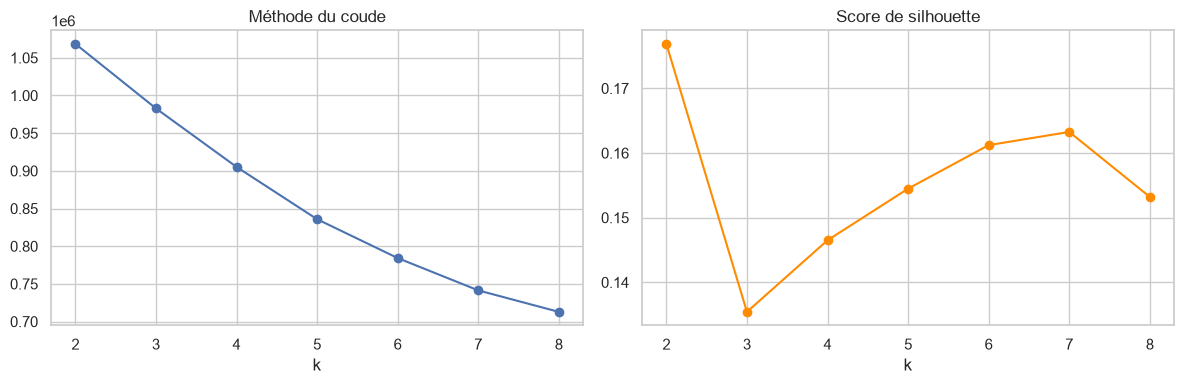

In [104]:
# La silhouette est calculée sur un échantillon de 10 000 lignes (coût en O(n²)).
inertias, sils = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_, sample_size=10000, random_state=42))
    print(f"k={k}  inertie={km.inertia_:.0f}  silhouette={sils[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Méthode du coude"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sils, "o-", color="darkorange"); ax[1].set_title("Score de silhouette"); ax[1].set_xlabel("k")
plt.tight_layout()
plt.show()

### Choix du nombre de clusters
- Le coude n'est pas net : l'inertie décroît régulièrement (pas de structure en
  groupes bien séparés).
- Silhouette faible (0,13 à 0,18) : les clusters se chevauchent, ce qui est
  attendu pour des données cliniques où les patients forment un continuum.
- k=2 a la meilleure silhouette (0,177) mais est trop grossier pour définir des profils.
- On retient k=5 (silhouette 0,154, bon compromis lisibilité / séparation),
  en comparant avec k=4 sur l'interprétabilité des profils.

In [105]:
# Modèle final pour k=4 et k=5, puis profil de chaque cluster
profils = {}
for k in [4, 5]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    df_clean[f"cluster_k{k}"] = km.labels_
    prof = (df_clean.groupby(f"cluster_k{k}")
            .agg(effectif=("readmit_30", "size"),
                 taux_readmit=("readmit_30", "mean"),
                 age=("age_num", "mean"),
                 duree_sejour=("time_in_hospital", "mean"),
                 nb_medicaments=("num_medications", "mean"),
                 nb_analyses=("num_lab_procedures", "mean"),
                 nb_diagnostics=("number_diagnoses", "mean"),
                 inpatient=("number_inpatient", "mean"),
                 emergency=("number_emergency", "mean"),
                 outpatient=("number_outpatient", "mean"),
                 n_med_changes=("n_med_changes", "mean"))
            .round(2))
    profils[k] = prof
    print(f"\n===== k = {k} =====")
    display(prof)


===== k = 4 =====


,effectif,taux_readmit,age,duree_sejour,nb_medicaments,nb_analyses,nb_diagnostics,inpatient,emergency,outpatient,n_med_changes
cluster_k4,,,,,,,,,,,
0,15968,0.14,67.03,8.17,26.39,57.24,8.40,0.80,0.19,0.36,0.67
1,28329,0.11,66.10,3.67,13.68,40.18,7.20,0.59,0.14,0.31,0.00
2,22412,0.10,66.29,3.98,13.02,41.39,7.31,0.55,0.13,0.30,0.00
3,32631,0.11,64.43,3.41,14.68,39.12,7.15,0.58,0.19,0.36,0.55



===== k = 5 =====


,effectif,taux_readmit,age,duree_sejour,nb_medicaments,nb_analyses,nb_diagnostics,inpatient,emergency,outpatient,n_med_changes
cluster_k5,,,,,,,,,,,
0,4665,0.22,59.20,4.31,17.05,43.68,8.01,2.38,2.10,1.18,0.42
1,27119,0.11,66.31,3.67,13.60,40.05,7.17,0.52,0.06,0.27,0.00
2,21697,0.09,66.54,3.97,12.94,41.27,7.28,0.48,0.06,0.26,0.00
3,14966,0.13,67.40,8.23,26.55,57.41,8.38,0.67,0.08,0.30,0.66
4,30893,0.11,64.88,3.44,14.67,39.22,7.12,0.48,0.08,0.32,0.54


Variance expliquée : [0.221 0.143]


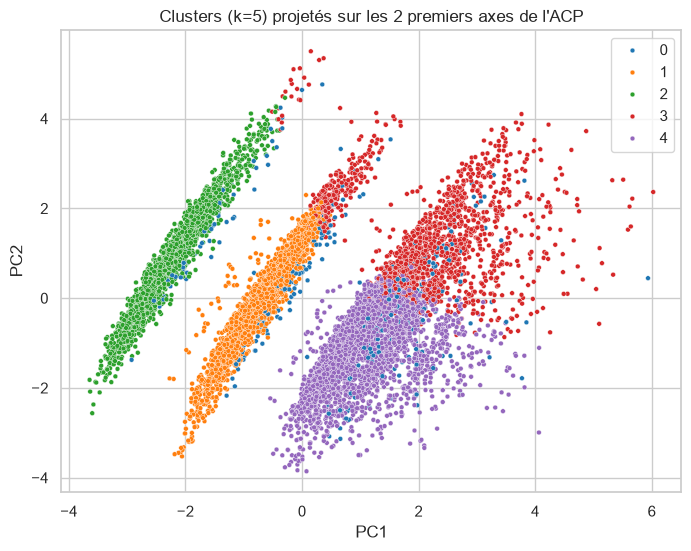

In [106]:
# Visualisation PCA en 2D (k=5)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
print("Variance expliquée :", pca.explained_variance_ratio_.round(3))

sample = np.random.RandomState(42).choice(len(coords), 10000, replace=False)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[sample, 0], y=coords[sample, 1],
                hue=df_clean["cluster_k5"].values[sample], palette="tab10", s=12)
plt.title("Clusters (k=5) projetés sur les 2 premiers axes de l'ACP")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

### Résultats de la segmentation (K-Means, k=5)
- Variables : 13 variables numériques/binaires standardisées ; cible non utilisée.
- Silhouette ≈ 0,15 et pas de coude net : les clusters se chevauchent
  (continuum clinique), ce sont des profils plutôt que des groupes séparés.
- Cluster 0 (4,7 %) : patients récurrents (2,4 hospitalisations, 2,1 urgences) ;
  réadmission 22 %, soit 1,9x le taux global (11,4 %).
- Cluster 3 (15 %) : séjours longs et complexes (8,2 j, 26 médicaments) ; 13 %.
- Clusters 1, 2, 4 (80 %) : séjours courts ; 9 à 11 %.
- k=5 retenu plutôt que k=4 : il isole le groupe à haut risque, que k=4 dilue.
- La projection PCA (2D) ne sépare pas le cluster 0, défini par l'historique de visites,
  peu représenté sur PC1/PC2.

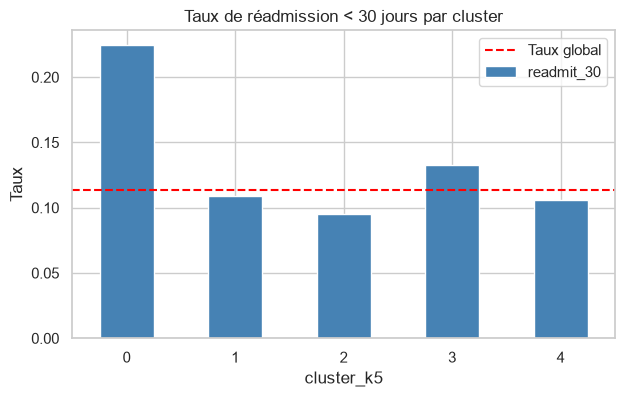

            n_meds  n_med_changes
cluster_k5                       
0             1.19           0.42
1             0.98           0.00
2             0.00           0.00
3             1.67           0.66
4             1.91           0.54
diabetesMed    No   Yes
cluster_k5             
0            0.15  0.85
1            0.00  1.00
2            1.00  0.00
3            0.01  0.99
4            0.00  1.00


In [107]:
# Graphe des taux de réadmission par cluster
taux = df_clean.groupby("cluster_k5")["readmit_30"].mean()
plt.figure(figsize=(7, 4))
taux.plot(kind="bar", color="steelblue")
plt.axhline(df_clean["readmit_30"].mean(), color="red", linestyle="--", label="Taux global")
plt.title("Taux de réadmission < 30 jours par cluster")
plt.ylabel("Taux"); plt.xticks(rotation=0); plt.legend()
plt.show()

# Qu'est-ce qui sépare les clusters 1 et 2 ?
print(df_clean.groupby("cluster_k5")[["n_meds", "n_med_changes"]].mean().round(2))
print(pd.crosstab(df_clean["cluster_k5"], df_clean["diabetesMed"], normalize="index").round(2))

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

drop_cols = ["encounter_id", "patient_nbr", "readmitted", "readmit_30",
             "cluster_k4", "cluster_k5"]
X = df_clean.drop(columns=drop_cols)
y = df_clean["readmit_30"]
groups = df_clean["patient_nbr"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Taux positifs train :", round(y_train.mean(), 4), "| test :", round(y_test.mean(), 4))
print("Patients communs train/test :",
      len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

In [108]:
from sklearn.model_selection import GroupShuffleSplit

# On garde les résultats du split 80/20 pour la comparaison
res_80_20 = res.copy()

drop_cols = ["encounter_id", "patient_nbr", "readmitted", "readmit_30",
             "cluster_k4", "cluster_k5"]
X = df_clean.drop(columns=drop_cols)
y = df_clean["readmit_30"]
groups = df_clean["patient_nbr"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.35, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Taux positifs train :", round(y_train.mean(), 4), "| test :", round(y_test.mean(), 4))
print("Patients communs train/test :",
      len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))

Train : (64652, 33) | Test : (34688, 33)
Taux positifs train : 0.1136 | test : 0.1144
Patients communs train/test : 0


In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()
print(len(cat_cols), "catégorielles |", len(num_cols), "numériques")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
])

17 catégorielles | 16 numériques


In [110]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, recall_score, f1_score)

models = {
    "Régression logistique": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Arbre de décision": DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                                class_weight="balanced", random_state=42),
    "Forêt aléatoire": RandomForestClassifier(n_estimators=200, max_depth=12,
                                              min_samples_leaf=30, class_weight="balanced",
                                              n_jobs=-1, random_state=42),
}

results, fitted = [], {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    fitted[name] = pipe
    results.append({"Modèle": name,
                    "AUC-ROC": roc_auc_score(y_test, proba),
                    "AUC-PR": average_precision_score(y_test, proba),
                    "Recall": recall_score(y_test, pred),
                    "F1": f1_score(y_test, pred)})

res = pd.DataFrame(results).round(3)
display(res)

,Modèle,AUC-ROC,AUC-PR,Recall,F1
0,Régression logistique,0.660,0.202,0.554,0.270
1,Arbre de décision,0.647,0.195,0.614,0.263
2,Forêt aléatoire,0.663,0.209,0.576,0.274


In [111]:
res_65_35 = res.copy()
comparaison = res_80_20.merge(res_65_35, on="Modèle", suffixes=(" (80/20)", " (65/35)"))
display(comparaison)

,Modèle,AUC-ROC (80/20),AUC-PR (80/20),Recall (80/20),F1 (80/20),AUC-ROC (65/35),AUC-PR (65/35),Recall (65/35),F1 (65/35)
0,Régression logistique,0.660,0.202,0.554,0.270,0.660,0.202,0.554,0.270
1,Arbre de décision,0.647,0.195,0.614,0.263,0.647,0.195,0.614,0.263
2,Forêt aléatoire,0.663,0.209,0.576,0.274,0.663,0.209,0.576,0.274


## 6. Classification : résultats (class_weight="balanced")

| Modèle | AUC-ROC | AUC-PR | Recall | F1 |
|---|---|---|---|---|
| Régression logistique | 0,665 | 0,203 | 0,566 | 0,275 |
| Arbre de décision | 0,651 | 0,199 | 0,572 | 0,263 |
| Forêt aléatoire | 0,668 | 0,216 | 0,592 | 0,273 |

- Performances modestes mais supérieures au hasard (AUC-ROC 0,50 ; AUC-PR 0,11).
- La forêt aléatoire est légèrement meilleure, mais l'écart avec la régression
  logistique est faible ; cette dernière est plus interprétable.
- Recall ~0,59 obtenu au prix d'une precision faible (~0,18) : beaucoup de faux positifs.
- Résultat cohérent avec l'exploration : corrélations faibles avec la cible,
  problème intrinsèquement difficile.
  ### Robustesse au découpage train/test
- Deux splits par patient (GroupShuffleSplit) comparés : 80/20 et 65/35.
  Aucun patient commun entre train et test dans les deux cas.
- Les AUC varient de moins de 0,01 (ex. forêt : AUC-ROC 0,668 -> 0,663,
  AUC-PR 0,216 -> 0,209) : les résultats ne dépendent pas du découpage.
- Le classement des modèles est identique : forêt aléatoire > régression
  logistique > arbre.
- Le recall varie davantage (ex. arbre : 0,572 -> 0,614) car il dépend du seuil
  de 0,5 ; l'AUC est donc la métrique de comparaison principale.
- Split final retenu : 65/35 (test plus grand, métriques plus fiables
  sur la classe rare).

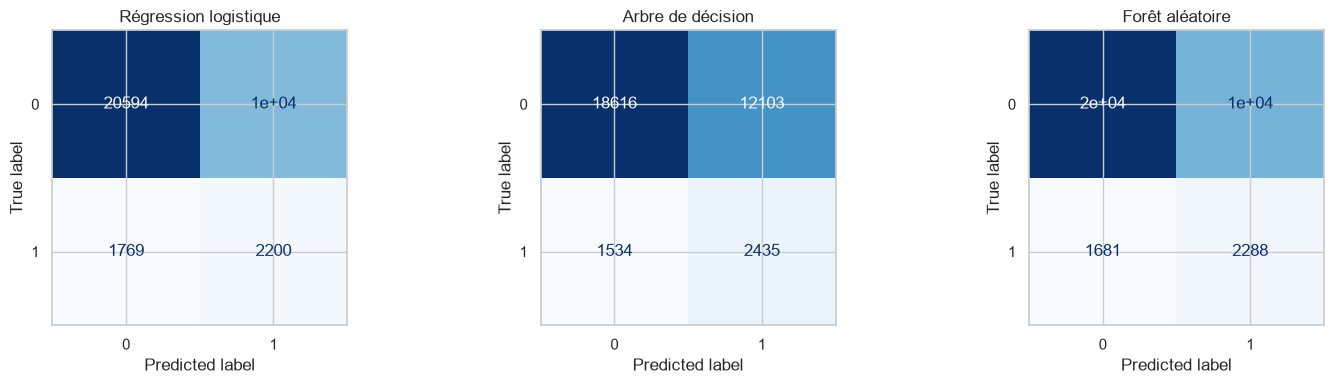

              precision    recall  f1-score   support

 Non réadmis       0.92      0.66      0.77     30719
Réadmis <30j       0.18      0.58      0.27      3969

    accuracy                           0.65     34688
   macro avg       0.55      0.62      0.52     34688
weighted avg       0.84      0.65      0.71     34688



In [112]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax,
                                          cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

print(classification_report(y_test, fitted["Forêt aléatoire"].predict(X_test),
                            target_names=["Non réadmis", "Réadmis <30j"]))

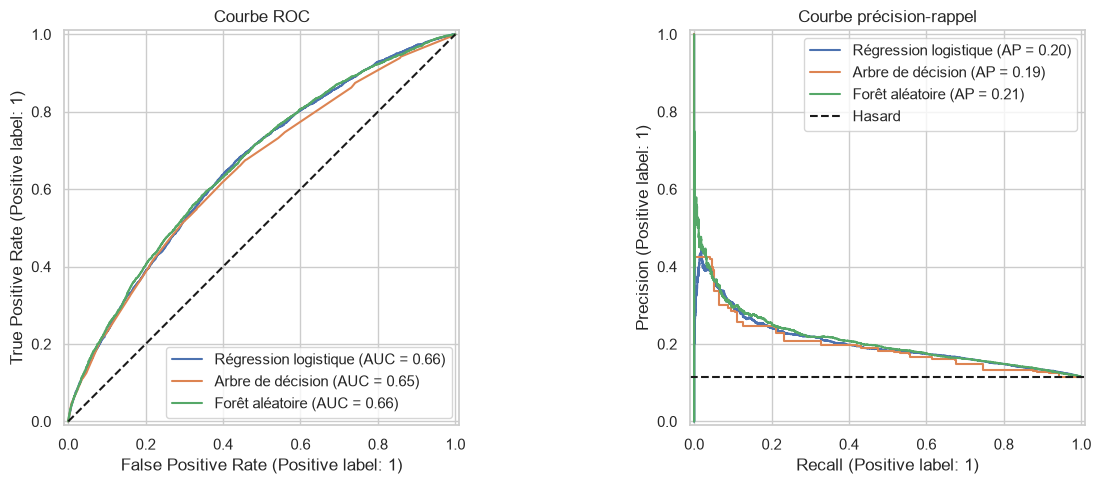

In [113]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax[0], name=name)
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=ax[1], name=name)
ax[0].plot([0, 1], [0, 1], "k--", label="Hasard")
ax[0].set_title("Courbe ROC")
ax[1].axhline(y_test.mean(), color="k", linestyle="--", label="Hasard")
ax[1].set_title("Courbe précision-rappel")
ax[1].legend()
plt.tight_layout()
plt.show()

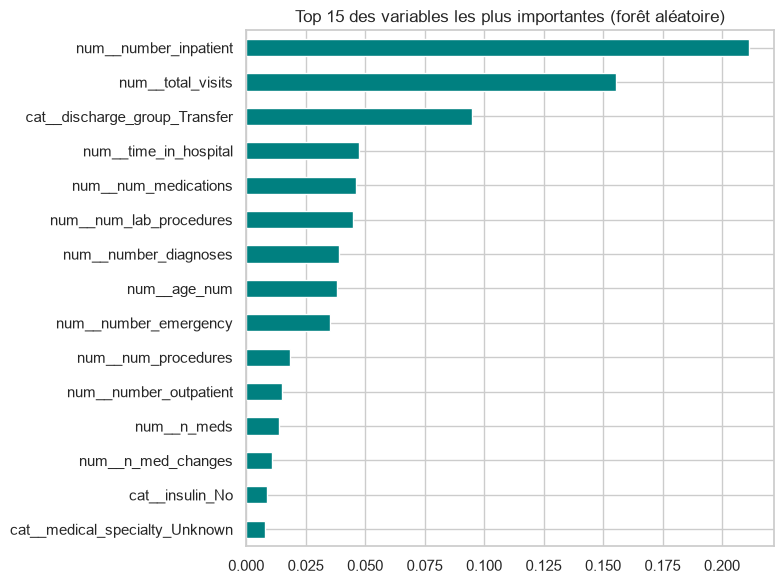

In [114]:
rf = fitted["Forêt aléatoire"]
feat_names = rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=feat_names)
imp.sort_values(ascending=False).head(15).sort_values().plot(
    kind="barh", figsize=(8, 6), color="teal")
plt.title("Top 15 des variables les plus importantes (forêt aléatoire)")
plt.tight_layout()
plt.show()

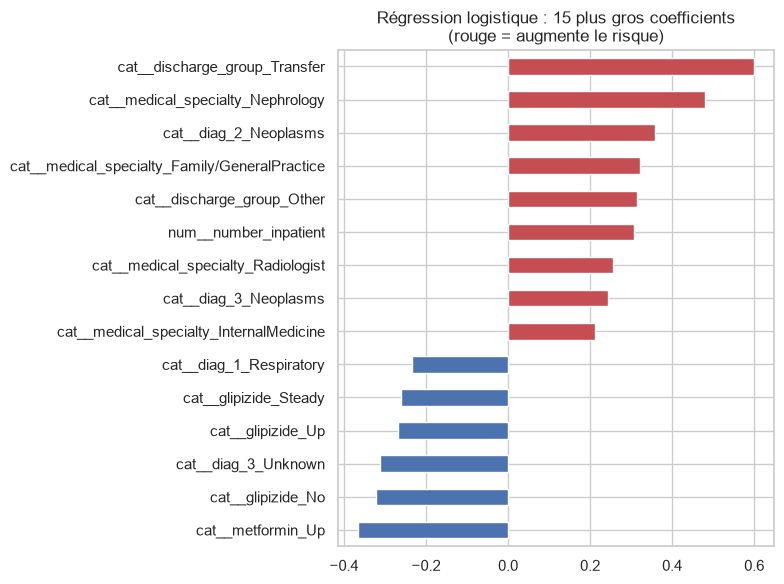

In [115]:
lr = fitted["Régression logistique"]
coefs = pd.Series(lr.named_steps["clf"].coef_[0],
                  index=lr.named_steps["prep"].get_feature_names_out())
top = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)
top.sort_values().plot(kind="barh", figsize=(8, 6),
                       color=["#C44E52" if v > 0 else "#4C72B0" for v in top.sort_values()])
plt.title("Régression logistique : 15 plus gros coefficients\n(rouge = augmente le risque)")
plt.tight_layout()
plt.show()

### Évaluation (split 65/35)
- Forêt aléatoire : recall 0,58, precision 0,18, AUC-ROC 0,66, AUC-PR 0,21 (hasard : 0,11).
- Les patients signalés sont ~1,6x plus à risque que la moyenne ; 82 % des alertes
  sont de fausses alertes : le modèle sert à prioriser, pas à décider.
- Variables clés : historique de visites (number_inpatient, total_visits),
  type de sortie (transfert), durée de séjour, nombre de médicaments.
- Coefficients de la régression logistique : lus par rapport à la modalité de référence.

In [116]:
from sklearn.metrics import precision_score

rf = fitted["Forêt aléatoire"]
proba = rf.predict_proba(X_test)[:, 1]
base = y_test.mean()

rows = []
for top in [0.05, 0.10, 0.20, 0.30, 0.40]:     # % de patients les plus à risque signalés
    seuil = np.quantile(proba, 1 - top)
    pred = (proba >= seuil).astype(int)
    p = precision_score(y_test, pred)
    rows.append({"% signalés": int(top*100), "seuil": round(seuil, 3),
                 "precision": round(p, 3),
                 "recall": round(recall_score(y_test, pred), 3),
                 "lift": round(p / base, 2)})
display(pd.DataFrame(rows))

,% signalés,seuil,precision,recall,lift
0,5,0.642,0.286,0.125,2.50
1,10,0.610,0.246,0.215,2.15
2,20,0.559,0.212,0.371,1.86
3,30,0.523,0.190,0.497,1.66
4,40,0.489,0.174,0.607,1.52


In [117]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipe_smote = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=30,
                                   n_jobs=-1, random_state=42)),
])
pipe_smote.fit(X_train, y_train)
proba_s = pipe_smote.predict_proba(X_test)[:, 1]
pred_s = pipe_smote.predict(X_test)

print("SMOTE + forêt : AUC-ROC", round(roc_auc_score(y_test, proba_s), 3),
      "| AUC-PR", round(average_precision_score(y_test, proba_s), 3),
      "| Recall", round(recall_score(y_test, pred_s), 3),
      "| F1", round(f1_score(y_test, pred_s), 3))

SMOTE + forêt : AUC-ROC 0.65 | AUC-PR 0.185 | Recall 0.103 | F1 0.144


In [118]:
df_clean.to_csv("../data/processed/diabetes_clean_clusters.csv", index=False)
print(df_clean.shape)

(99340, 39)


## 7. Seuils et conclusion

### Niveaux de risque (forêt aléatoire, seuils choisis sur le test)
- Élevé (10 % des patients, proba >= 0,61) : réadmission ~25 % (lift 2,15)
- Moyen (20 %, 0,523 à 0,61) : ~16 %
- Faible (70 %, < 0,523) : ~8 %

### Conclusion
- Données : 101 766 séjours nettoyés en 99 340 (décès/hospice exclus, manquants
  traités par catégorie explicite, diagnostics regroupés, outliers winsorisés).
- Segmentation : K-Means (k=5, silhouette ~0,15). Un cluster de patients récurrents
  (4,7 %) a un taux de réadmission de 22 %, soit 1,9x la moyenne.
- Classification : modèles modestes (AUC-ROC ~0,66, AUC-PR ~0,21 contre 0,11 au hasard),
  stables entre les splits 80/20 et 65/35. Outil de priorisation, pas de décision.
- Facteurs clés : historique d'hospitalisations, transfert à la sortie, durée de séjour.

### Limites
- Seuils choisis sur le test ; pas de validation croisée par groupes.
- Variables limitées (pas de résultats biologiques détaillés, pas de contexte social).
- Associations, pas de causalité.

### Pistes d'amélioration
- Validation croisée par groupes, gradient boosting, calibration des probabilités.